# Background & Motivation

Metabolic Syndrome has more than doubled globally over the past two decades,
now affecting approximately 28% of adults worldwide - an estimated 1.54 billion
people as of 2023. It significantly increases the risk of cardiovascular disease, stroke, and type 2 diabetes

This project applies machine learning techniques to identify the likelihood of Metabolic Syndrome using clinical and socioeconomic data, supporting early risk detection and better healthcare decision-making

***(Bigna et al., Nature Communications, 2025)***



# What is Metabolic Syndrome?

Metabolic Syndrome is a group of interconnected metabolic conditions that substantially raise the risk of cardiovascular disease and type 2 diabetes.


This project follows the NCEP ATP III criteria, one of the most widely adopted standards in clinical and epidemiological research, where Metabolic Syndrome is diagnosed when **at least three of the following five risk factors are present**: increased waist circumference, high triglyceride levels, low HDL cholesterol, hypertension history, and elevated fasting blood glucose levels.

# Imports

In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
pd.set_option('display.max_columns', 50)


from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.inspection import permutation_importance


In [2]:
plt.style.use(['seaborn-v0_8-white', 'seaborn-v0_8-notebook'])
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
df = pd.read_csv('https://query.data.world/s/rqkgm3xu42jh63yuw4m7ewttf2m6yt?dws=00000')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2401 entries, 0 to 2400
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   seqn               2401 non-null   int64  
 1   Age                2401 non-null   int64  
 2   Sex                2401 non-null   object 
 3   Marital            2193 non-null   object 
 4   Income             2284 non-null   float64
 5   Race               2401 non-null   object 
 6   WaistCirc          2316 non-null   float64
 7   BMI                2375 non-null   float64
 8   Albuminuria        2401 non-null   int64  
 9   UrAlbCr            2401 non-null   float64
 10  UricAcid           2401 non-null   float64
 11  BloodGlucose       2401 non-null   int64  
 12  HDL                2401 non-null   int64  
 13  Triglycerides      2401 non-null   int64  
 14  MetabolicSyndrome  2401 non-null   object 
dtypes: float64(5), int64(6), object(4)
memory usage: 281.5+ KB


,seqn,Age,Sex,Marital,Income,Race,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,MetabolicSyndrome
0,62161,22,Male,Single,8200.0,White,81.0,23.3,0,3.88,4.9,92,41,84,No MetSyn
1,62164,44,Female,Married,4500.0,White,80.1,23.2,0,8.55,4.5,82,28,56,No MetSyn
2,62169,21,Male,Single,800.0,Asian,69.6,20.1,0,5.07,5.4,107,43,78,No MetSyn
3,62172,43,Female,Single,2000.0,Black,120.4,33.3,0,5.22,5.0,104,73,141,No MetSyn
4,62177,51,Male,Married,NaN,Asian,81.1,20.1,0,8.13,5.0,95,43,126,No MetSyn


# Data Cleaning


## Initial inspection

In [4]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
seqn,2401.0,67030.674302,2823.565114,62161.0,64591.000,67059.00,69495.000,71915.0
Age,2401.0,48.691795,17.632852,20.0,34.000,48.00,63.000,80.0
Income,2284.0,4005.253940,2954.032186,300.0,1600.000,2500.00,6200.000,9000.0
WaistCirc,2316.0,98.307254,16.252634,56.2,86.675,97.00,107.625,176.0
BMI,2375.0,28.702189,6.662242,13.4,24.000,27.70,32.100,68.7
Albuminuria,2401.0,0.154102,0.422780,0.0,0.000,0.00,0.000,2.0
UrAlbCr,2401.0,43.626131,258.272829,1.4,4.450,7.07,13.690,5928.0
UricAcid,2401.0,5.489046,1.439358,1.8,4.500,5.40,6.400,11.3
BloodGlucose,2401.0,108.247813,34.820657,39.0,92.000,99.00,110.000,382.0
HDL,2401.0,53.369429,15.185537,14.0,43.000,51.00,62.000,156.0


In [5]:
df.describe(include='object').T

,count,unique,top,freq
Sex,2401,2,Female,1211
Marital,2193,5,Married,1192
Race,2401,6,White,933
MetabolicSyndrome,2401,2,No MetSyn,1579


### Early Observations

* Metabloic sundrome dataset contains 2401 rows and 15 columns

* Compared to the data dictionary, this column require further action:

  * ***Albuminuria***: identified as integer , needs to be converted to object (ordinal feature)

  


* ***UrAlbCr||Triglycerides***  Both features show a large gap between the 75th percentile and the maximum values. Does this indicate outliers, or are these unrealistic values that need to be addressed?

## Duplicated

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.duplicated(subset=['seqn']).sum()

np.int64(0)

## Data Types

In [8]:
df.dtypes

,0
seqn,int64
Age,int64
Sex,object
Marital,object
Income,float64
Race,object
WaistCirc,float64
BMI,float64
Albuminuria,int64
UrAlbCr,float64


In [9]:
df['Albuminuria'] = df['Albuminuria'].astype('object')

## Inspecting Categorical Columns & Addressing Inconsistent Values

In [10]:
# Inspecting Categorical columns
cat_cols = df.select_dtypes("object").columns
cat_cols

Index(['Sex', 'Marital', 'Race', 'Albuminuria', 'MetabolicSyndrome'], dtype='object')

In [11]:
for col in cat_cols:
  print(f"Value counts for {col}")
  print(df[col].value_counts())
  print("\n")

Value counts for Sex
Sex
Female    1211
Male      1190
Name: count, dtype: int64


Value counts for Marital
Marital
Married      1192
Single        498
Divorced      242
Widowed       166
Separated      95
Name: count, dtype: int64


Value counts for Race
Race
White          933
Black          548
Asian          349
Hispanic       257
MexAmerican    253
Other           61
Name: count, dtype: int64


Value counts for Albuminuria
Albuminuria
0    2089
1     254
2      58
Name: count, dtype: int64


Value counts for MetabolicSyndrome
MetabolicSyndrome
No MetSyn    1579
MetSyn        822
Name: count, dtype: int64




## Inappropriate / unusual data

In [12]:
df.describe().round(2)

,seqn,Age,Income,WaistCirc,BMI,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides
count,2401.00,2401.00,2284.00,2316.00,2375.00,2401.00,2401.00,2401.00,2401.00,2401.00
mean,67030.67,48.69,4005.25,98.31,28.70,43.63,5.49,108.25,53.37,128.13
std,2823.57,17.63,2954.03,16.25,6.66,258.27,1.44,34.82,15.19,95.32
min,62161.00,20.00,300.00,56.20,13.40,1.40,1.80,39.00,14.00,26.00
25%,64591.00,34.00,1600.00,86.68,24.00,4.45,4.50,92.00,43.00,75.00
50%,67059.00,48.00,2500.00,97.00,27.70,7.07,5.40,99.00,51.00,103.00
75%,69495.00,63.00,6200.00,107.62,32.10,13.69,6.40,110.00,62.00,150.00
max,71915.00,80.00,9000.00,176.00,68.70,5928.00,11.30,382.00,156.00,1562.00


In [13]:
df['Triglycerides'].sort_values(ascending=False).head(10)

,Triglycerides
2092,1562
1016,1311
829,979
2196,814
2076,700
1740,688
681,681
148,668
1979,666
650,626


In [14]:
df['UrAlbCr'].sort_values(ascending=False).head(10)

,UrAlbCr
1557,5928.00
2070,4462.81
910,3666.67
2196,3500.00
140,3284.62
50,3267.57
246,2750.00
324,2403.85
2027,2403.85
1438,2360.66


* Based on the medical context and the observed value ranges, these extreme values in Triglycerides and UrAlbCr are not data entry errors but rather clinical outliers

In [15]:
# copy dataset after cleaning process to use for modeling and avoid data leakage
df_model = df.copy()

## Missing Values

In [16]:
df.isna().sum()

,0
seqn,0
Age,0
Sex,0
Marital,208
Income,117
Race,0
WaistCirc,85
BMI,26
Albuminuria,0
UrAlbCr,0


In [17]:
df.isna().sum() / len(df) * 100

,0
seqn,0.000000
Age,0.000000
Sex,0.000000
Marital,8.663057
Income,4.872970
Race,0.000000
WaistCirc,3.540192
BMI,1.082882
Albuminuria,0.000000
UrAlbCr,0.000000


<Axes: >

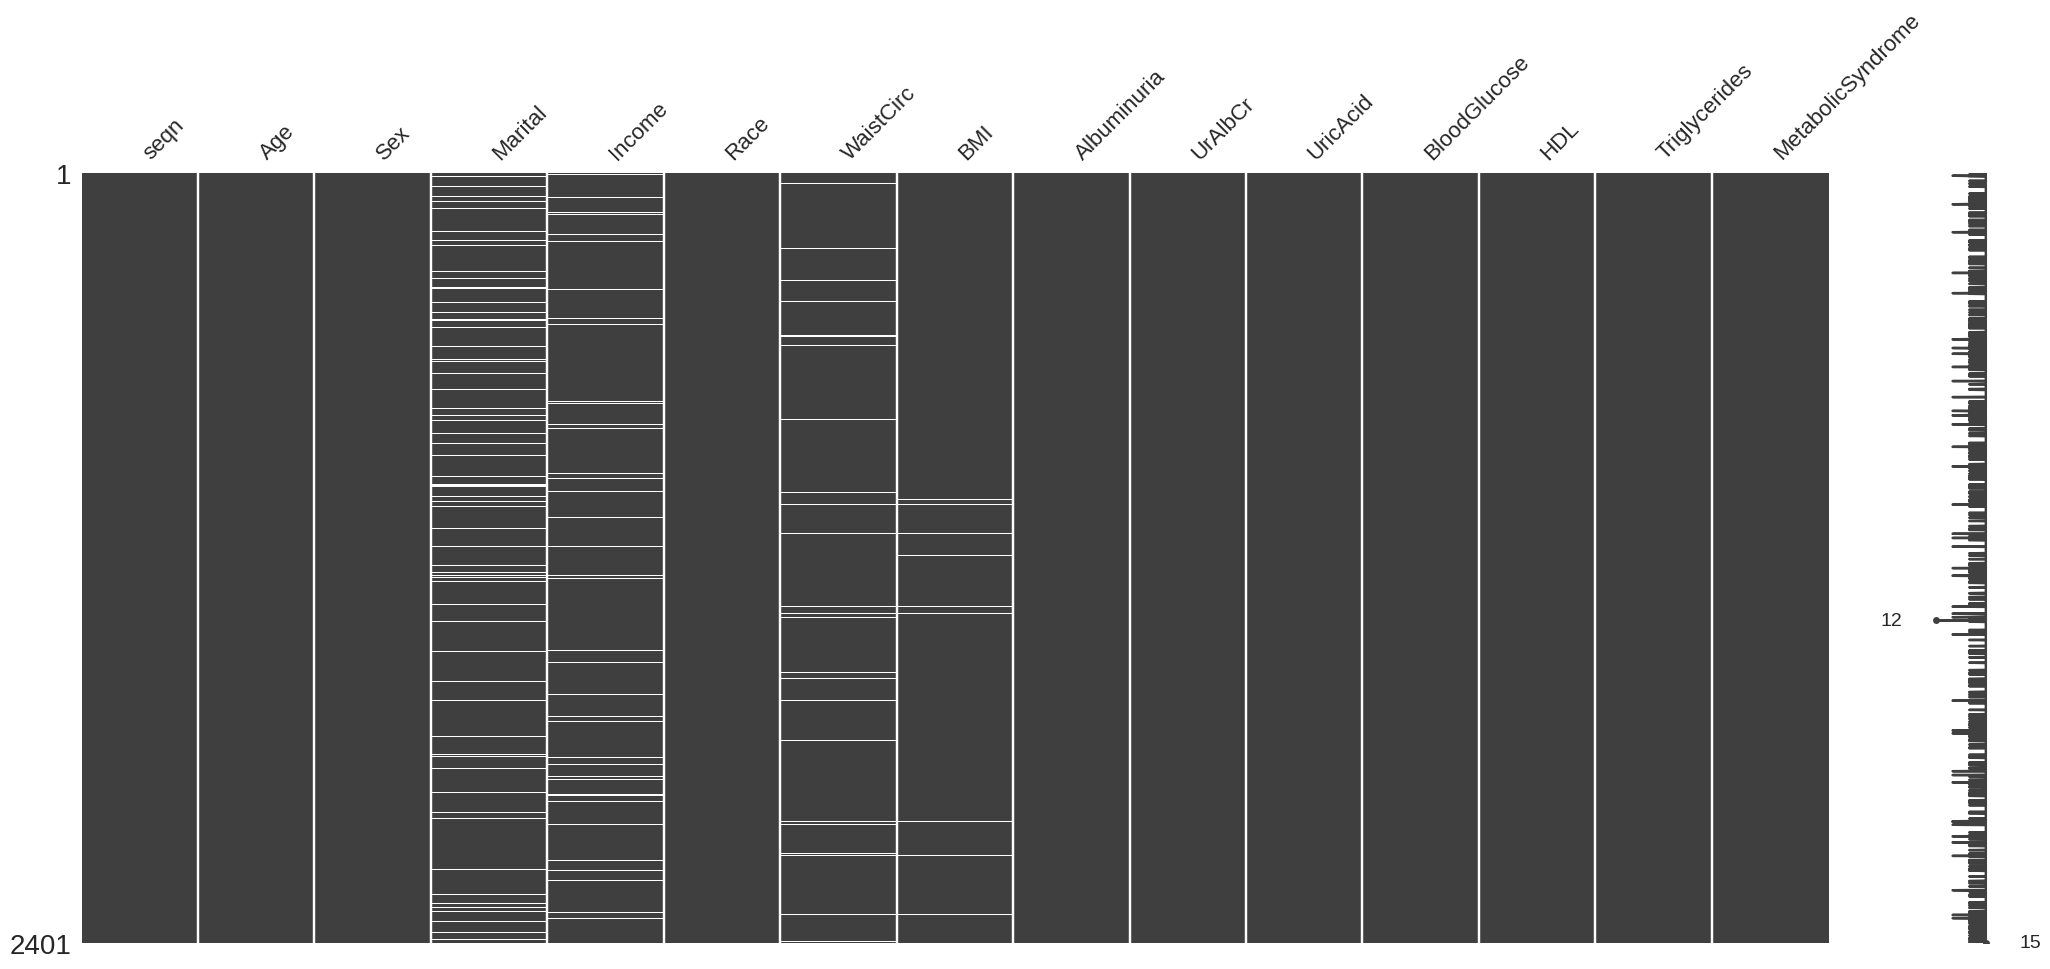

In [18]:
msno.matrix(df)

<Axes: >

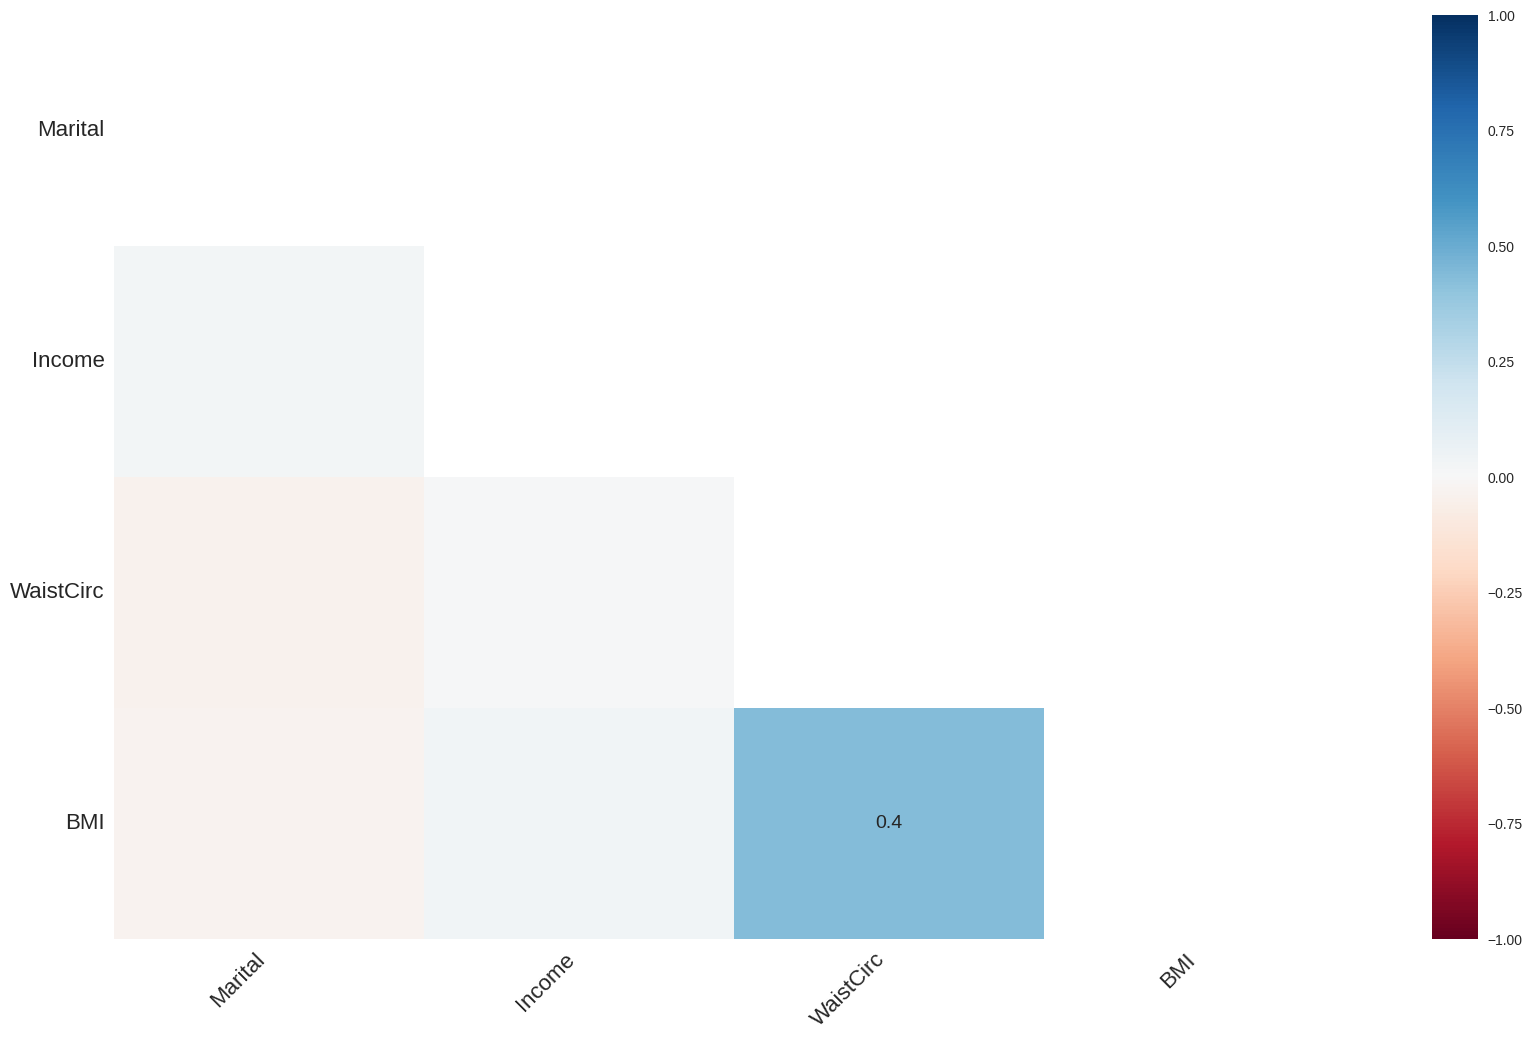

In [19]:
import missingno as msno
msno.heatmap(df)

In [20]:
# Group-Median imputation
df['WaistCirc'] = df.groupby(['Sex', 'Race'])['WaistCirc'].transform(lambda x: x.fillna(x.median()))
df['BMI'] = df.groupby(['Sex', 'Race'])['BMI'].transform(lambda x: x.fillna(x.median()))

df['Income'] = df['Income'].fillna(df['Income'].median())
df['Marital'] = df['Marital'].fillna('MISSING')

In [21]:
df.isna().sum()

,0
seqn,0
Age,0
Sex,0
Marital,0
Income,0
Race,0
WaistCirc,0
BMI,0
Albuminuria,0
UrAlbCr,0


# Exploratory Data Analysis - EDA

## Univariate Plots

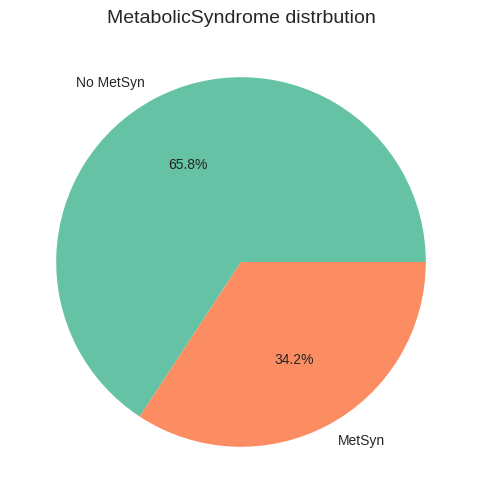

In [22]:
counts = df['MetabolicSyndrome'].value_counts()

fig, ax = plt.subplots(figsize=(6,6))
ax.pie(counts, labels=counts.index, autopct='%1.1f%%')
ax.set_title("MetabolicSyndrome distrbution" , fontsize=14)
plt.show()

* The target variable is MetabolicSyndrome with 65.8% No MetSyn and 34.2% MetSyn. A slight class imbalance exists

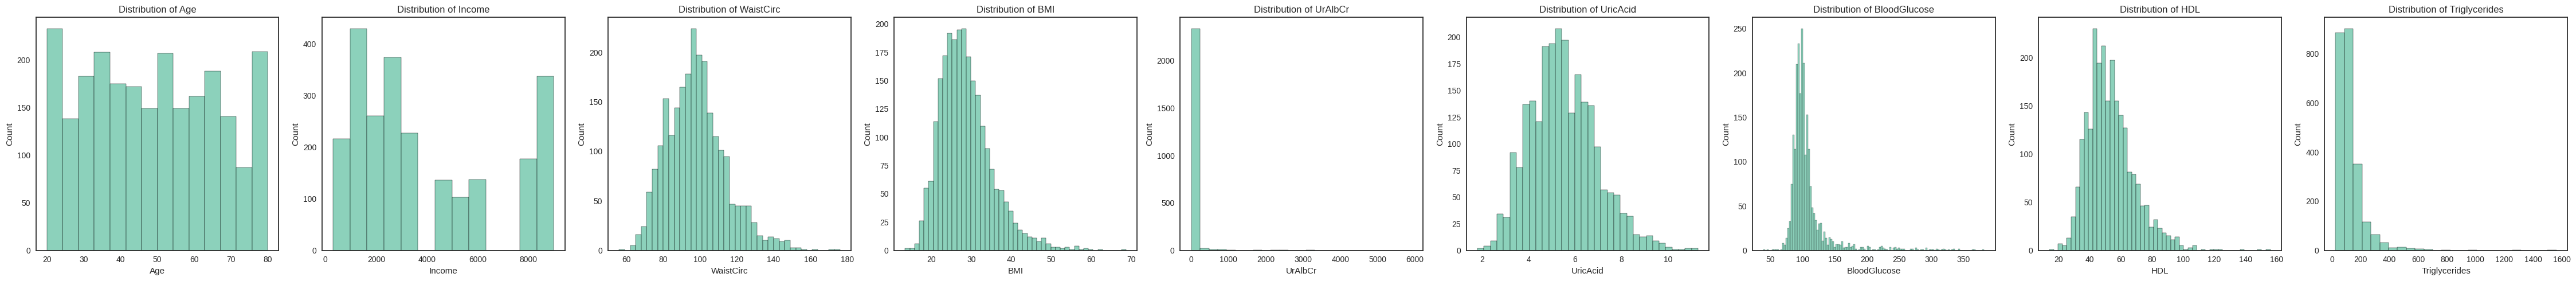

In [23]:
cols = ['Age', 'Income', 'WaistCirc', 'BMI', 'UrAlbCr',
        'UricAcid', 'BloodGlucose', 'HDL', 'Triglycerides']

fig, axes = plt.subplots(figsize=(45, 5), nrows=1, ncols=9)

i = 0
for col in cols:
    if col in ['UrAlbCr', 'Triglycerides']:
        sns.histplot(df[col], bins=25, ax=axes[i])
    else:
        sns.histplot(df[col], ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    i += 1

fig.tight_layout()
plt.show()

- **Age:** Most participants are between 20-80 years old with a relatively
  uniform distribution

- **Income:** Values appear in brackets rather than continuous,
  reflecting how NHANES collects income data.

- **WaistCirc:** Most values fall between 80-110 cm with a right skew,
  and only a few extreme cases exceed 150 cm.

- **BMI:** Most patients have a BMI between 25-35, with only a few
  cases on either extreme.

- **UrAlbCr:** Most values are concentrated near zero with a long tail
  extending toward higher values.

- **UricAcid:** Most patients have uric acid levels between 4-7 mg/dL,
  with only a few cases on either extreme

- **BloodGlucose:** Most patients have glucose levels between 80-110 mg/dL,
  with only a few cases exceeding 200 mg/dL.

- **HDL:** Most patients have HDL levels between 40-60 mg/dL,
  with a right skew and only a few extreme cases.

- **Triglycerides:** Most patients have levels below 200 mg/dL,
  but there is a long tail extending toward very high values

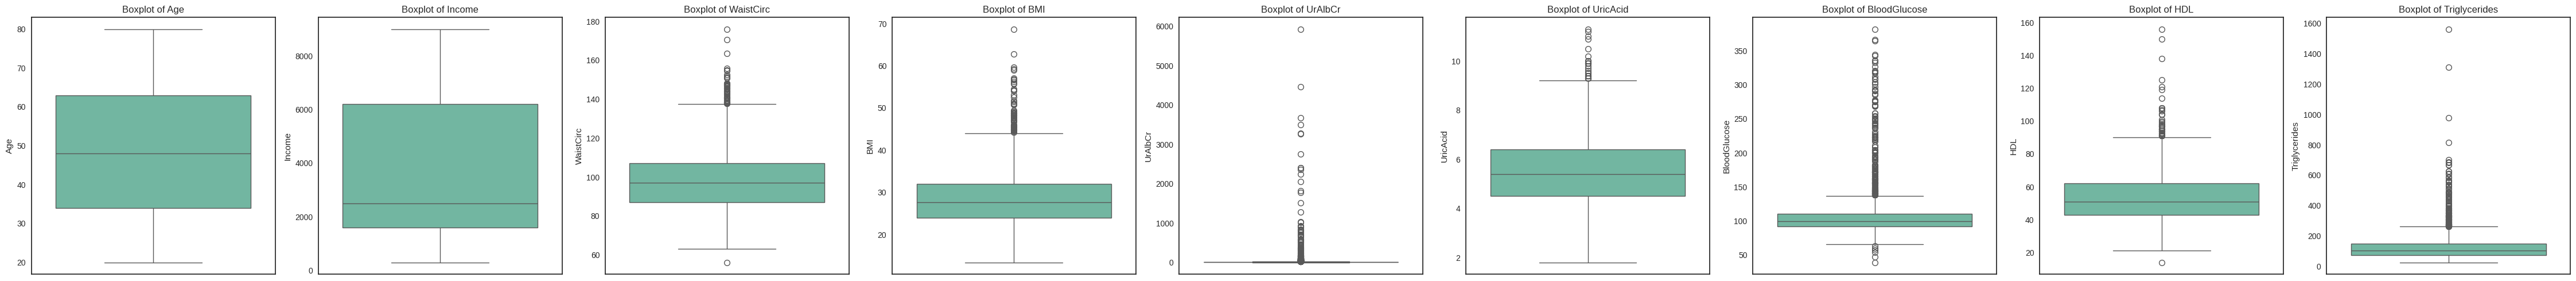

In [24]:
cols = ['Age', 'Income', 'WaistCirc', 'BMI', 'UrAlbCr',
        'UricAcid', 'BloodGlucose', 'HDL', 'Triglycerides']

fig, axes = plt.subplots(figsize=(45, 5), nrows=1, ncols=9)

i = 0
for col in cols:
    sns.boxplot(df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    i += 1

fig.tight_layout()
plt.show()

Here we can observe the outliers across features:

- **Age:** No outliers detected.
- **Income:** No outliers detected.
- **WaistCirc:** A few outliers on the high end, with some cases exceeding 150 cm.
- **BMI:** A few outliers on the high end, with some cases exceeding 60.
- **UricAcid:** A few mild outliers on both ends.
- **HDL:** A few outliers on the high end, with some cases exceeding 120 mg/dL.
- **BloodGlucose:** Many outliers on the high end, with some cases exceeding 200 mg/dL.
- **Triglycerides:** Significant outliers on the high end, with some cases
  exceeding 1000 mg/dL
- **UrAlbCr:** The most significant outliers, with some cases reaching up to
  6000+

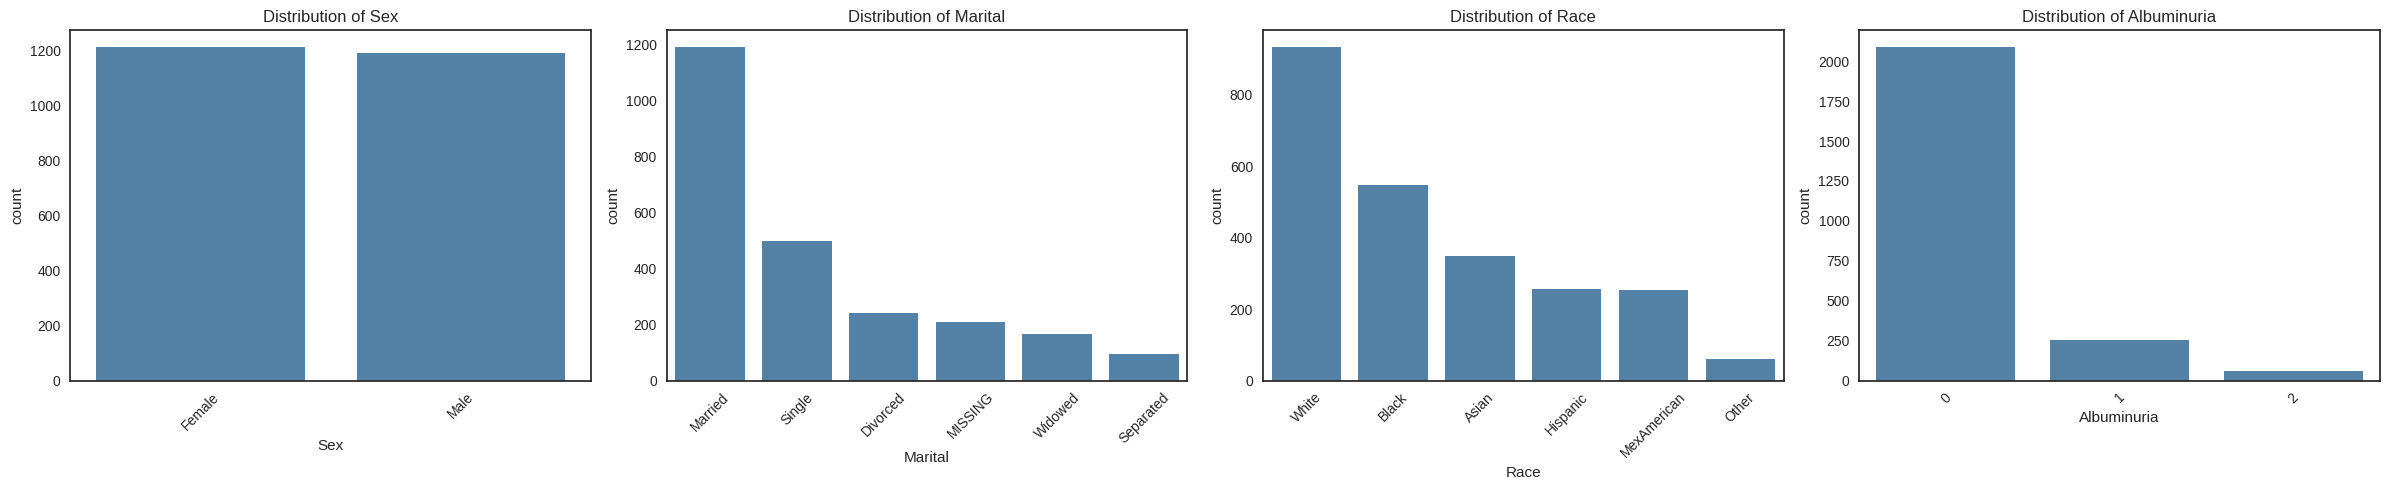

In [25]:
cols = ['Sex', 'Marital', 'Race', 'Albuminuria']

fig, axes = plt.subplots(figsize=(24, 5), nrows=1, ncols=4)

i = 0
for col in cols:
    sns.countplot(data=df, x=col, ax=axes[i], color='steelblue',order=df[col].value_counts().index)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(f"Distribution of {col}")
    i += 1

fig.tight_layout()
plt.show()

- **Sex:** The dataset is well balanced between Female and Male patients.

- **Marital:** Married is the most frequent category

- **Race:** White patients dominate, followed by Black and Asian.

- **Albuminuria:** Most patients have no albuminuria (0),
  with very few showing (1) or  (2) levels.

## Multivariate Plots

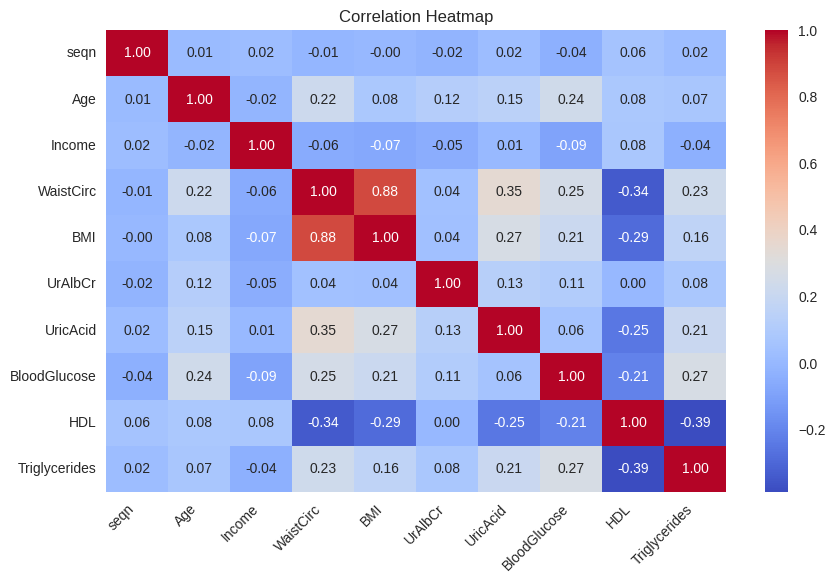

In [26]:
corr_matrix = df.corr(numeric_only=True)

fig , ax = plt.subplots()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title("Correlation Heatmap") ;

* WaistCirc and BMI show a high correlation (0.88), suggesting
multicollinearity

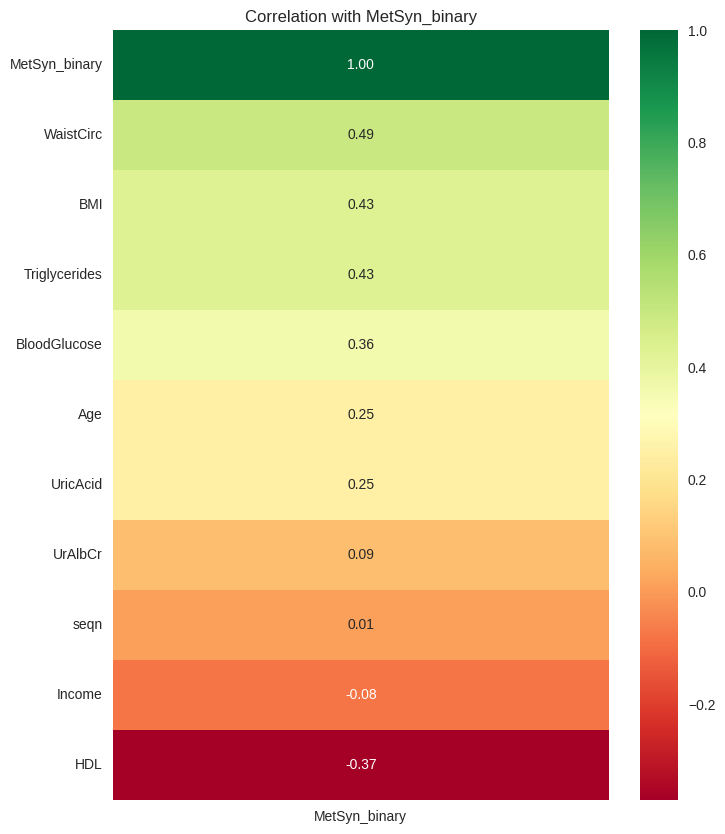

In [27]:
df['MetSyn_binary'] = df['MetabolicSyndrome'].map({'MetSyn': 1, 'No MetSyn': 0})

fig, ax = plt.subplots(figsize=(8, 10))
corr_matrix = df.select_dtypes(include='number').corr()
target_corr = corr_matrix[['MetSyn_binary']].sort_values(ascending=False, by='MetSyn_binary')
sns.heatmap(target_corr, annot=True, cmap='RdYlGn', fmt='.2f')
ax.set_title('Correlation with MetSyn_binary') ;

*  WaistCirc (0.49), BMI (0.43), and Triglycerides (0.43)
show the strongest positive correlation with Metabolic Syndrome

*  HDL (-0.37) shows the strongest negative correlation, confirming that higher HDL levels are protective against the condition

* Incomeshow near-zero correlation,suggesting minimal predictive value.

In [28]:
df.drop(columns=['MetSyn_binary'] , inplace=True)

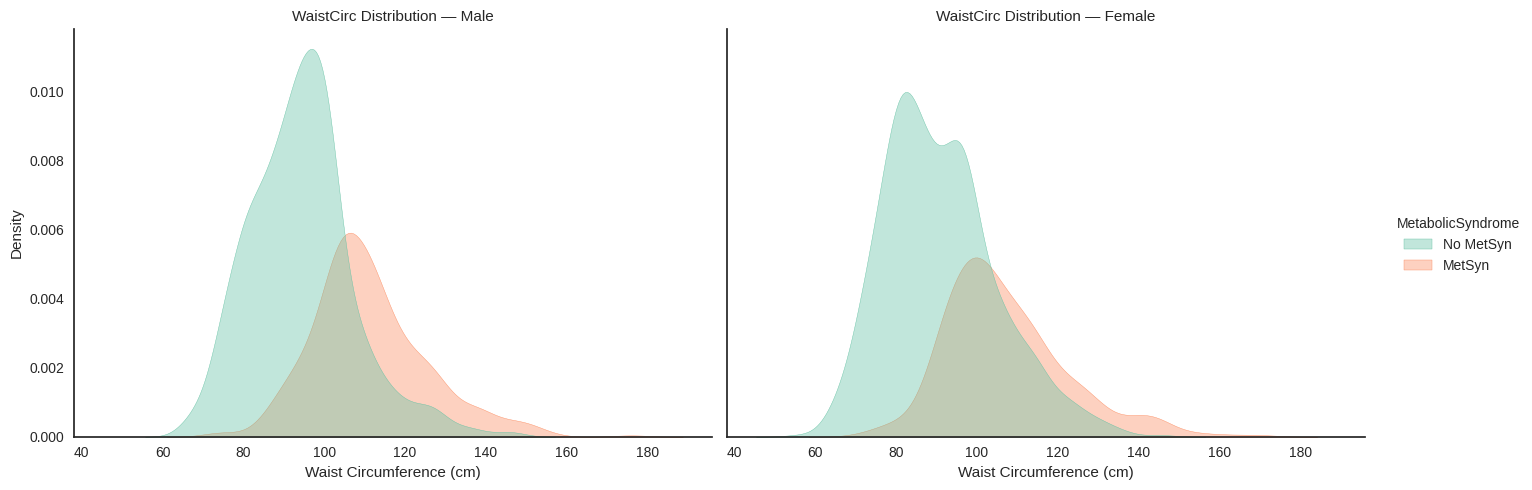

In [29]:
g = sns.displot(data=df, x='WaistCirc', hue='MetabolicSyndrome', col='Sex', kind='kde', fill=True, alpha=0.4, height=5, aspect=1.4)

g.set_titles("WaistCirc Distribution — {col_name}" , fontsize = 16)
g.set_axis_labels("Waist Circumference (cm)", "Density") ;

* Among males, MetSyn individuals show a clear right shift centered around
108 cm compared to 95 cm for No MetSyn

* Waist circumference offers sharper classification for males , as there is more overlap between female groups .

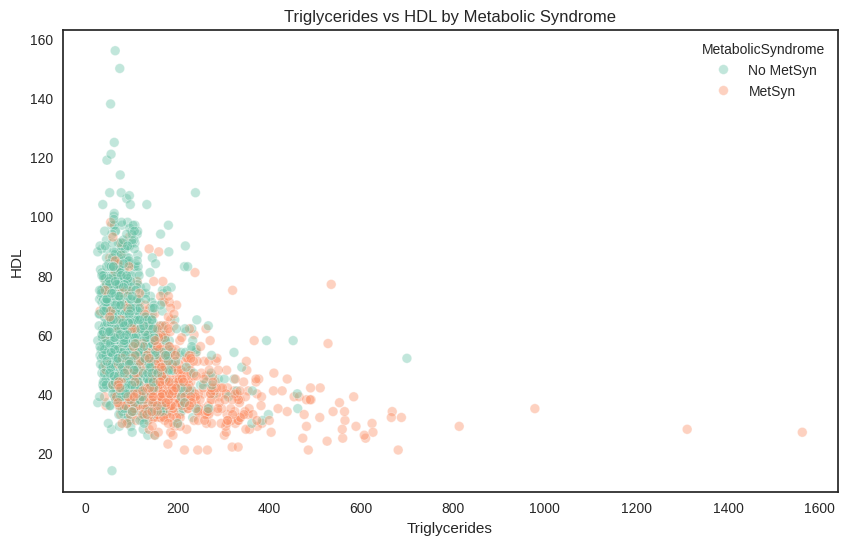

In [30]:
g = sns.scatterplot(data=df, x='Triglycerides', y='HDL', hue='MetabolicSyndrome', alpha=0.4)

g.set_title('Triglycerides vs HDL by Metabolic Syndrome')
g.set_xlabel('Triglycerides')
g.set_ylabel('HDL') ;

* Individuals diagnosed with Metabolic Syndrome tend to cluster in the high Triglycerides and low HDL region of the plot, forming a risk zone

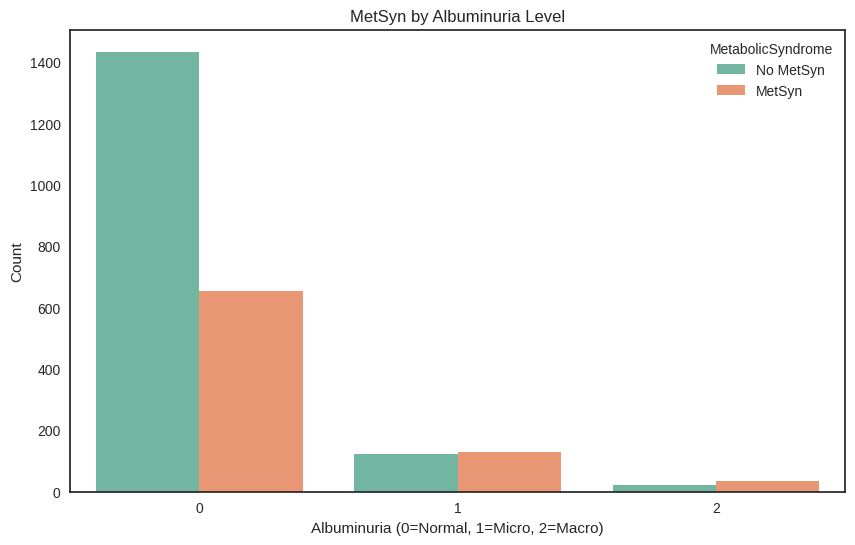

In [31]:
g = sns.countplot(data=df, x='Albuminuria', hue='MetabolicSyndrome')
g.set_title('MetSyn by Albuminuria Level')
g.set_xlabel('Albuminuria (0=Normal, 1=Micro, 2=Macro)')
g.set_ylabel('Count') ;

* As Albuminuria severity increases, Metabolic Syndrome cases become more prevalent, indicating there is a link between kidney dysfunction and Metabolic Syndrome.

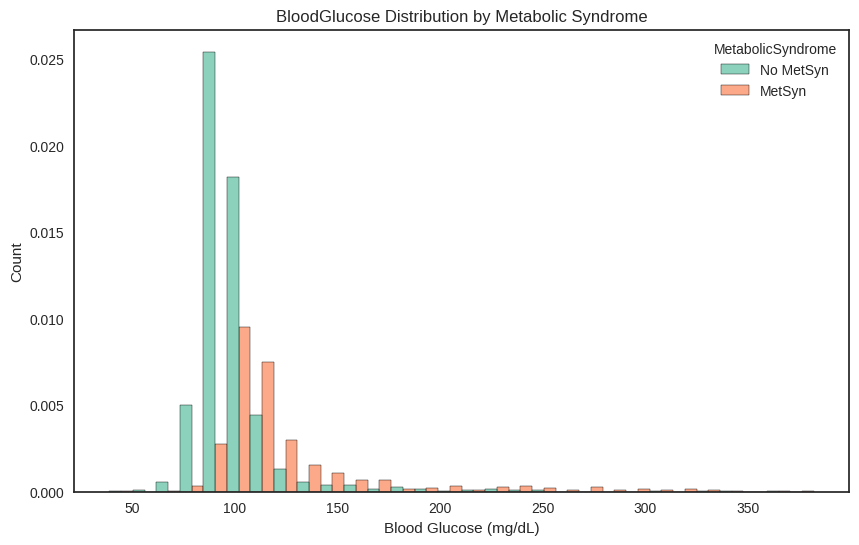

In [32]:
g = sns.histplot(data=df, x='BloodGlucose', hue='MetabolicSyndrome', bins=30, stat='density',multiple='dodge')
g.set_title('BloodGlucose Distribution by Metabolic Syndrome')
g.set_xlabel('Blood Glucose (mg/dL)')
g.set_ylabel('Count') ;

* Individuals without Metabolic Syndrome show Blood Glucose levels concentrated around 90 mg/dL, whereas those with the syndrome show a distinct shift toward the 110–130 mg/dL range.

# PreProcessing

### Imputation
- **WaistCirc & BMI**  - A custom `GroupedMedianImputer` was built to impute
  missing values using the median per (Sex, Race) group, as EDA revealed
  significant variation across these groups .

- **Income** - Imputed using global median, as the missing rate (4.9%)
  was low and no strong pattern with other features.

- **Marital** - Imputed using the most frequent category, as the missing
  rate (8.7%) showed no strong pattern with other features
### Encoding
- **Albuminuria** -  OrdinalEncoder, as it has a meaningful order
  (Normal < Micro < Macro).

- **Sex** - OneHotEncoder with `drop='if_binary'` to avoid redundant
  information .
- **Race & Marital** -  OneHotEncoder with no drop
### Scaling
- **RobustScaler** was applied to all numerical features, as EDA revealed
  significant outliers in Triglycerides and UrAlbCr. RobustScaler is less
  sensitive to outliers compared to StandardScaler.

In [33]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2401 entries, 0 to 2400
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   seqn               2401 non-null   int64  
 1   Age                2401 non-null   int64  
 2   Sex                2401 non-null   object 
 3   Marital            2193 non-null   object 
 4   Income             2284 non-null   float64
 5   Race               2401 non-null   object 
 6   WaistCirc          2316 non-null   float64
 7   BMI                2375 non-null   float64
 8   Albuminuria        2401 non-null   object 
 9   UrAlbCr            2401 non-null   float64
 10  UricAcid           2401 non-null   float64
 11  BloodGlucose       2401 non-null   int64  
 12  HDL                2401 non-null   int64  
 13  Triglycerides      2401 non-null   int64  
 14  MetabolicSyndrome  2401 non-null   object 
dtypes: float64(5), int64(5), object(5)
memory usage: 281.5+ KB


In [34]:
df_model['MetabolicSyndrome'].value_counts(normalize=True)

,proportion
MetabolicSyndrome,
No MetSyn,0.657643
MetSyn,0.342357


- The positive class (1) represents patients diagnosed with metabolicsyndrome .
- A slight class imbalance exists

In [35]:
class GroupedMedianImputer(BaseEstimator, TransformerMixin):
    def __init__(self, group_cols, target_cols):
        self.group_cols = group_cols
        self.target_cols = target_cols

    def fit(self, X, y=None):
        self.medians_ = {}
        self.global_medians_ = {}
        for col in self.target_cols:
            self.medians_[col] = X.groupby(self.group_cols)[col].median()
            self.global_medians_[col] = X[col].median()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.target_cols:
            X[col] = X[col].astype(float)
            X[col] = X[col].fillna(
                X[self.group_cols].apply(tuple, axis=1).map(self.medians_[col]))
            X[col] = X[col].fillna(float(self.global_medians_[col]))
        return X

In [36]:
def classification_metrics(y_true, y_pred, label="",
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict


def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

### Train-Test Split

In [37]:
cols_to_drop = ['MetabolicSyndrome' , 'seqn']
X = df_model.drop(columns=cols_to_drop)
y = df_model['MetabolicSyndrome']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)
y_train.value_counts(normalize=True).sort_index()

,proportion
MetabolicSyndrome,
MetSyn,0.342222
No MetSyn,0.657778


In [38]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1800 entries, 1714 to 373
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            1800 non-null   int64  
 1   Sex            1800 non-null   object 
 2   Marital        1652 non-null   object 
 3   Income         1709 non-null   float64
 4   Race           1800 non-null   object 
 5   WaistCirc      1735 non-null   float64
 6   BMI            1782 non-null   float64
 7   Albuminuria    1800 non-null   object 
 8   UrAlbCr        1800 non-null   float64
 9   UricAcid       1800 non-null   float64
 10  BloodGlucose   1800 non-null   int64  
 11  HDL            1800 non-null   int64  
 12  Triglycerides  1800 non-null   int64  
dtypes: float64(5), int64(4), object(4)
memory usage: 196.9+ KB


### Numeric

In [39]:
num_cols = X_train.select_dtypes("number").columns
print("Numeric Columns:", num_cols)
impute_median = SimpleImputer(strategy='median')
scaler = RobustScaler()
num_pipe = make_pipeline(impute_median, scaler)
num_tuple = ('numeric', num_pipe, num_cols)

Numeric Columns: Index(['Age', 'Income', 'WaistCirc', 'BMI', 'UrAlbCr', 'UricAcid',
       'BloodGlucose', 'HDL', 'Triglycerides'],
      dtype='object')


### Ordinal

In [40]:
ordinal_cols = ['Albuminuria']
print("Ordinal Columns:", ordinal_cols)
albuminuria_order = [[0, 1, 2]]
ord_encoder = OrdinalEncoder(categories=albuminuria_order)
ord_pipe = make_pipeline(ord_encoder)
ord_tuple = ('ordinal', ord_pipe, ordinal_cols)

Ordinal Columns: ['Albuminuria']


### Nominal

In [41]:
ohe_cols = ['Sex', 'Race', 'Marital']
print("OneHotEncoder Columns:", ohe_cols)
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='if_binary')
ohe_pipe = make_pipeline(ohe_encoder)
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)

OneHotEncoder Columns: ['Sex', 'Race', 'Marital']


### Column Transformer

In [42]:
group_imputer = GroupedMedianImputer(group_cols=['Sex', 'Race'],target_cols=['WaistCirc', 'BMI'])

preprocessor = ColumnTransformer([num_tuple, ord_tuple, ohe_tuple],verbose_feature_names_out=False)

# Modeling

In [43]:
rf = RandomForestClassifier(random_state=42)
rf_pipe = make_pipeline(group_imputer, preprocessor, rf)
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('groupedmedianimputer',
                 GroupedMedianImputer(group_cols=['Sex', 'Race'],
                                      target_cols=['WaistCirc', 'BMI'])),
                ('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('robustscaler',
                                                                   RobustScaler())]),
                                                  Index(['Age', 'Income', 'WaistCirc', 'BMI', 'UrAlbCr', 'UricAcid',
       'Bl...
                                                 ('ordinal',
                                                  Pipeline(steps=[('ordinalencoder',
                                                                   OrdinalEncoder(categories=[[0,
                                                                                               1,
                                                                                               2]]))]),
                                                  ['Albuminuria']),
                                                 ('categorical',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Sex', 'Race', 'Marital'])],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

      MetSyn       1.00      1.00      1.00       616
   No MetSyn       1.00      1.00      1.00      1184

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



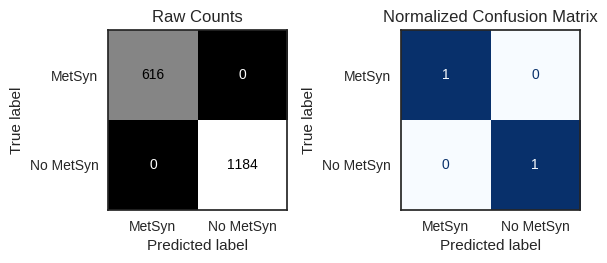


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

      MetSyn       0.81      0.81      0.81       206
   No MetSyn       0.90      0.90      0.90       395

    accuracy                           0.87       601
   macro avg       0.85      0.85      0.85       601
weighted avg       0.87      0.87      0.87       601



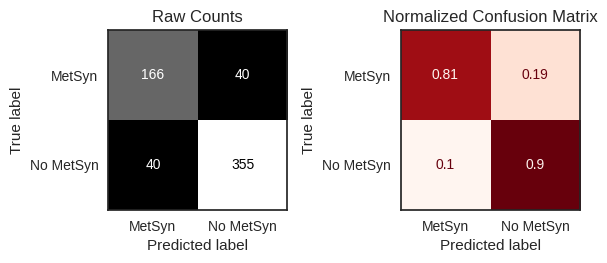

In [44]:
# Evaluate the default model
evaluate_classification(rf_pipe, X_train, y_train, X_test, y_test)

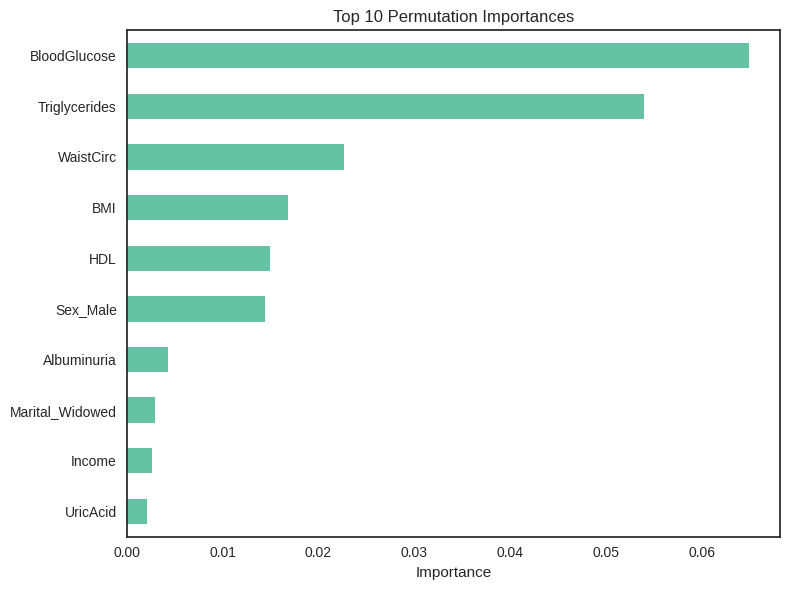

In [45]:
feature_names = rf_pipe.named_steps['columntransformer'].get_feature_names_out()

X_test_transformed = rf_pipe.named_steps['columntransformer'].transform(X_test)

result = permutation_importance(rf_pipe.named_steps['randomforestclassifier'],X_test_transformed, y_test,n_repeats=10, random_state=42)

perm_importances = pd.Series(result.importances_mean, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
perm_importances[:10].sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 10 Permutation Importances')
ax.set_xlabel('Importance')
fig.tight_layout()


In [46]:
def plot_metabolic_risk(df, column, bins, labels, title, xlabel, plot_type='bar'):

    df_temp = df.copy()
    group_col = column + '_Group'
    df_temp[group_col] = pd.cut(df_temp[column], bins=bins, labels=labels)

    total = df_temp.groupby(group_col, observed=False).size()
    sick = df_temp[df_temp['MetabolicSyndrome'] == 'MetSyn'].groupby(group_col, observed=False).size()

    risk_data = (sick / total).reset_index()
    risk_data.columns = ['Category', 'RiskProportion']

    fig, ax = plt.subplots(figsize=(12, 7))

    if plot_type == 'line':
        ax.plot(risk_data['Category'], risk_data['RiskProportion'], color='#1f77b4', linewidth=4, marker='o', markersize=12)
        ax.fill_between(risk_data['Category'].astype(str), risk_data['RiskProportion'], color='#1f77b4', alpha=0.15)
    else:
        sns.barplot(data=risk_data, x='Category', y='RiskProportion', palette='RdYlGn_r', ax=ax, hue='Category', legend=False)
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=12, fontweight='bold', xytext=(0, 9), textcoords='offset points')

    ax.set_title(title, fontsize=19, pad=25, fontweight='bold', color='#2c3e50')
    ax.set_xlabel(xlabel, fontsize=14, labelpad=15)
    ax.set_ylabel('Risk Probability', fontsize=14, labelpad=15)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.2)

    fig.tight_layout()

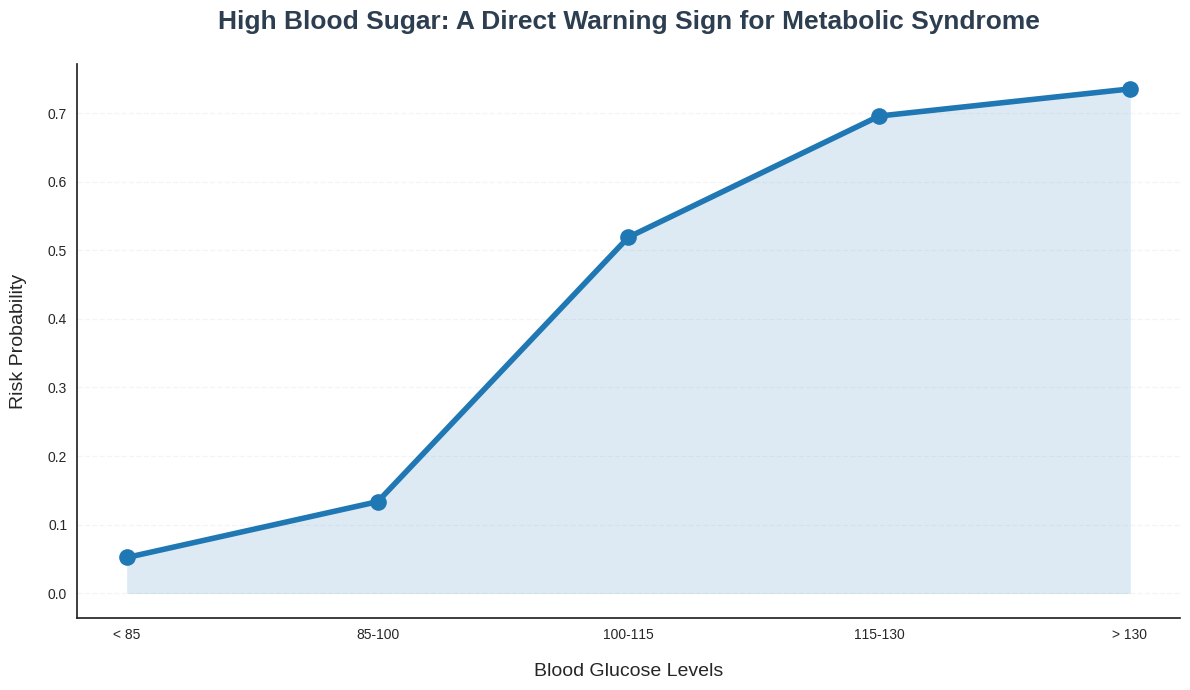

In [47]:
plot_metabolic_risk(df, 'BloodGlucose', [0, 85, 100, 115, 130, 400], ['< 85', '85-100', '100-115', '115-130', '> 130'],
    title='High Blood Sugar: A Direct Warning Sign for Metabolic Syndrome',
    xlabel='Blood Glucose Levels',
    plot_type='line'
)

* The chart reveals a striking inflection point: once fasting blood sugar crosses 100 mg/dL, the risk of Metabolic Syndrome more than triples, jumping from 14% to over 52% , data-driven jump aligns with the 100 mg/dL clinical threshold. It confirms that a simple blood test isn't just a number . . it’s a critical early warning system

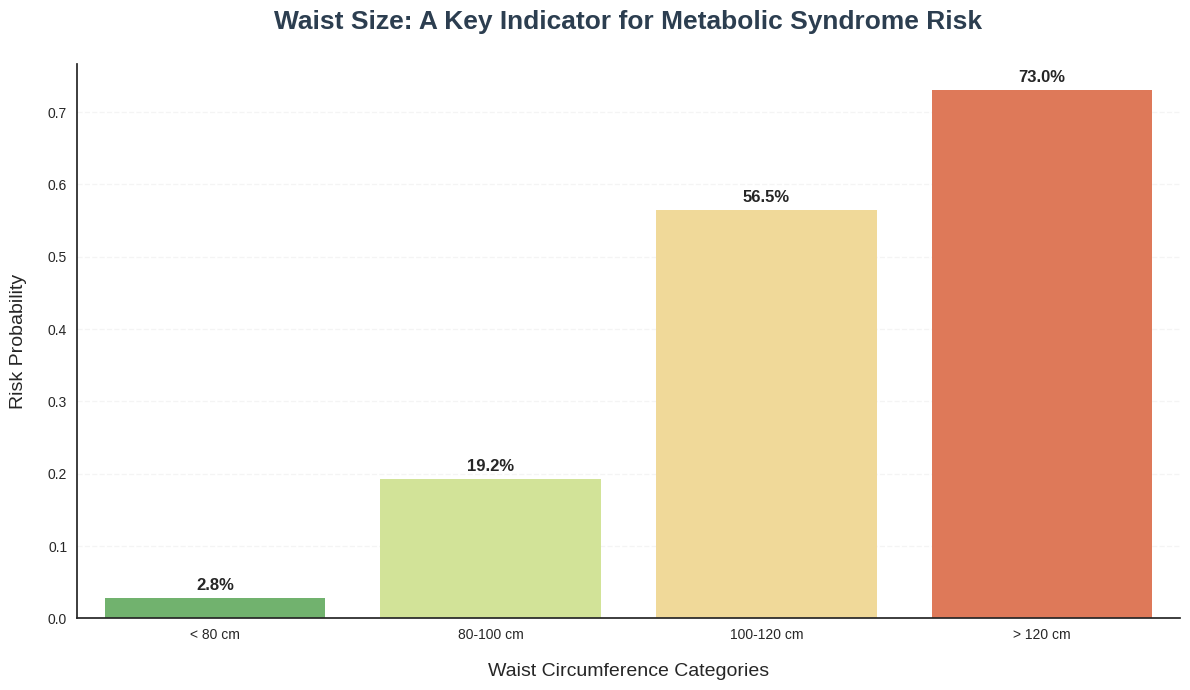

In [48]:
plot_metabolic_risk(
    df, 'WaistCirc', [0, 80, 100, 120, 200], ['< 80 cm', '80-100 cm', '100-120 cm', '> 120 cm'],
    title='Waist Size: A Key Indicator for Metabolic Syndrome Risk',
    xlabel='Waist Circumference Categories',
    plot_type='bar'
)

* Once waist circumference exceeds 100 cm, rising from 20% to over 56%. Individuals with a waist size above 120 cm face a 73% probability of Metabolic Syndrome